In [1]:
# Basic imports
import os
import re
import textwrap

# RAG components
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# LangChain tools
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

# LLM
from langchain_openai import ChatOpenAI

# DO NOT MODIFY THESE
from eval.eval_task1_quant import llm, eval_rag_chain_proj_query

# These are provided as reference
# You do not NEED to use these
from eval.eval_task1_quant import (
    baseline_hfe, baseline_vectorstore,
    baseline_retriever, baseline_rag_chain
)

from parser_SA import *

import json
from langchain_core.documents import Document

# General
# Functions for interacting with the operating system
import os

# Disable parallelism warnings from Hugging Face tokenizers
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Clean print statements
import textwrap

# Get PDFs as Document object
from langchain_community.document_loaders import PyMuPDFLoader

# Recursive parsing
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Dynamic Semantic Chunking
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_experimental.text_splitter import SemanticChunker

# For setting up vectorstore
from langchain_chroma import Chroma

# Supports literal conversion
import ast

# Option for easy text cleaning
from textblob import TextBlob

# Allows for async calls to llms
import asyncio

# For comparing serial vs. async calls
import time

# Clients for access TDAC hosted models via OpenAI APIs
from openai import OpenAI, AsyncOpenAI

# To measure semantic similarity
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# For sparse retrieval
from langchain_community.retrievers import BM25Retriever

# For Cross-Encoder retrieval
from sentence_transformers import CrossEncoder

# RAG components
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

# LangChain tools
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableLambda

# LLM
from langchain_openai import ChatOpenAI




In [2]:
# Standard library
import json
import logging
import operator
import os
import sys
from pathlib import Path
from pprint import pprint
from types import SimpleNamespace
from typing import Annotated, List, Literal
from tqdm import tqdm
import random

# Third party
import requests
from IPython.display import Image, display
from typing_extensions import NotRequired, TypedDict

# Pydantic
from pydantic import BaseModel, Field

# OpenAI
from openai import OpenAI

# LangChain Core
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

# LangChain potpurri
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEndpointEmbeddings, HuggingFaceEmbeddings
from langchain_chroma import Chroma
from chromadb.utils.embedding_functions import HuggingFaceEmbeddingServer

# LangChain OpenAI
from langchain_openai import ChatOpenAI

# LangChain Community
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.document_loaders import PyMuPDFLoader

# LangGraph
from langgraph.graph import StateGraph, END

# Add the PARENT directory (oa4910) to sys.path and load helper functions
sys.path.append(str(Path.cwd().parent))
from helper_code.rag.load_dataset import setup_embedding_function, load_db_from_dir, load_vectorstore

In [3]:
# Function to clean documents extracted from PDFs
def baseline_clean_doc(text: str) -> str:
    '''
    Function to clean PyMuPDFLoader documents created from the SRD5_OGL. 
    Contains a regex expression for a common header found in SRD5_OGL.
    '''
    HEADER = re.compile(
        r"""^
        Not\s+for\s+resale\.\s+
        Permission\s+granted\s+to\s+print\s+or\s+photocopy\s+this\s+document\s+for\s+personal\s+use\s+only\.\s+
        System\s+Reference\s+Document\s+5\.0\s*
        """,
        re.IGNORECASE | re.VERBOSE
    )

    text = text.replace("\xa0", " ")        # Normalize non-breaking spaces
    text = HEADER.sub("", text, count=1)    # Remove boilerplate header

    return text.strip()

In [4]:
# Text splitter used for baseline chunking
baseline_splitter = CharacterTextSplitter(
    separator="",
    chunk_size=3500,
    chunk_overlap=300,
)

In [5]:
# Path to documents
directory = "docs/projects"
proj_doc_paths = [os.path.join(directory, filename) for filename in os.listdir(directory) if filename.endswith('.pdf')]

# We will build the flat list directly
proj_docs_flat = []

for doc_path in proj_doc_paths:
    try:
        # 1. Parse the PDF using your custom logic
        boxes = FormTextExtractor(doc_path).extract_boxes()
        pds_dict = get_pds(boxes)
        
        # 2. Extract the Project ID (the top-level key) and the data payload
        project_id = list(pds_dict.keys())[0]
        project_data = pds_dict[project_id]
        
        # 3. Convert the nested dictionary into a structured string for the LLM to read.
        page_content = json.dumps(project_data, indent=2)
        
        # 4. Create the LangChain Document with ALL top section fields as metadata
        doc = Document(
            page_content=page_content,
            metadata={
                "source": doc_path,
                "project_id": project_id,
                "title": project_data.get("title"),
                "installation": project_data.get("installation"),
                "CWE": project_data.get("CWE"),
                "CCN": project_data.get("CCN"),
                "region": project_data.get("region"),
                "lead_proponent": project_data.get("lead_proponent"),
                "COCOM": project_data.get("COCOM"),
                "scope": project_data.get("scope"),
                "impact_if_not_provided": project_data.get("impact_if_not_provided")
            }
        )
        
        proj_docs_flat.append(doc)
        
    except Exception as e:
        print(f"Error processing {doc_path}: {type(e).__name__} - {e}")

# Verify
print(f'Total Documents Processed: {len(proj_docs_flat)}')

Total Documents Processed: 78


In [6]:

########## POM26 STRATEGY ##########
# Path to documents
directory = "docs/strategy/pom26"
strat26_doc_paths = [
    os.path.join(directory, filename) 
    for filename in os.listdir(directory) 
    if filename.endswith('.pdf')
    ]

# Extract text into documents
strat26_docs_multilevel = [
    PyMuPDFLoader(doc_path).load() 
    for doc_path in strat26_doc_paths
    ]

# Flatten docs into 1 dim list
strat26_docs_flat = [
    item 
    for sublist in strat26_docs_multilevel 
    for item in sublist
    ]

########## POM28 STRATEGY ##########
# Path to documents
directory = "docs/strategy/pom28"
strat28_doc_paths = [
    os.path.join(directory, filename) 
    for filename in os.listdir(directory) 
    if filename.endswith('.pdf')
    ]

# Extract text into documents
strat28_docs_multilevel = [
    PyMuPDFLoader(doc_path).load() 
    for doc_path in strat28_doc_paths
    ]

# Flatten docs into 1 dim list
strat28_docs_flat = [
    item 
    for sublist in strat28_docs_multilevel 
    for item in sublist
    ]

In [7]:
# Embedding model
embed_model_name = "sentence-transformers/all-MiniLM-L6-v2"
model_kwargs = {"device": "cpu"}
encode_kwargs = {"normalize_embeddings": False}

baseline_hfe = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs,
)

In [8]:
# Recursive text splitting
# `chunk_size` and `chunk_overlap` are tunable hyperparameters
# `separators` can also be used to specify what to split on
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

# Creates chunks from documents using the splitter
recursive_proj_docs = recursive_splitter.transform_documents(proj_docs_flat)
recursive_strat26_docs = recursive_splitter.transform_documents(strat26_docs_flat)
recursive_strat28_docs = recursive_splitter.transform_documents(strat28_docs_flat)

# Add unique chunk id as metadata
# Chromadb requires strings for metadata
# Crombadb will throw an error if id is 0
for i, chunk in enumerate(recursive_proj_docs, start=1):
    chunk.metadata['id'] = str(i)
for i, chunk in enumerate(recursive_strat26_docs, start=1):
    chunk.metadata['id'] = str(i)
for i, chunk in enumerate(recursive_strat28_docs, start=1):
    chunk.metadata['id'] = str(i)

# Create vectore store for base recursive method
# Saved locally
recursive_chunk_vectorstore_proj = Chroma.from_documents(
    documents=recursive_proj_docs, 
    embedding=baseline_hfe,
    persist_directory="databases/proj",
    ids=[doc.metadata["id"] for doc in recursive_proj_docs]
)
recursive_chunk_vectorstore_strat26 = Chroma.from_documents(
    documents=recursive_strat26_docs, 
    embedding=baseline_hfe,
    persist_directory="databases/strat26",
    ids=[doc.metadata["id"] for doc in recursive_strat26_docs]
)
recursive_chunk_vectorstore_strat28 = Chroma.from_documents(
    documents=recursive_strat28_docs, 
    embedding=baseline_hfe,
    persist_directory="databases/strat28",
    ids=[doc.metadata["id"] for doc in recursive_strat28_docs]
)


In [9]:
## GREEN ##
# No change from Lsn8 ipynb
API_KEY = "sk-UtrV9i5fFenmG6hvMss71A"
BASE_URL = "http://trac-malenia.ern.nps.edu:8080/inference/v1"

# Check the models available
model_ids = []

try:
    response = requests.get(
        f"{BASE_URL}/models",
        headers={"Authorization": f"Bearer {API_KEY}"}
    )
    response.raise_for_status()  
    info = response.json()
    
    for model in info['data']:
        model_ids.append(model['id'])
    model_id = info['data'][0]['id']
    print(f"Available Models: {model_ids}")
    print(f"\nDefault Selected Model Id: {model_id}")
except Exception as e:
    print(f"Error accessing model endpoint: {e}")

## YELLOW ##
# choose your desired model by updating model_id -- see the returned Available Models above and index based off that list
model_id = model_ids[2]
print(model_id)

# Create a model instance to use as your router -- HINT: which of the available models supports tool calling?
llm_md_tools = ChatOpenAI(
    base_url=BASE_URL,
    model=model_id,
    api_key=API_KEY,
    temperature=0,  
    name= "llama" # Name the LLM for langchain
)

# test the model's responsiveness
prompt = "Briefly explain the MILCON process?"

for chunk in llm_md_tools.stream(prompt):
    print(chunk.content, end='')

## YELLOW ## 
# Create a model instance to generate your responses, if you want to use a different one than above
# You can choose whichever model you'd like, but not all are likely to perform well for the given eval prompts
llm_gen_tools = ChatOpenAI(
    base_url=BASE_URL,
    model= model_ids[1],
    api_key=API_KEY,
    temperature=0.3,
    name="llama"
)

# test the model's responsiveness
prompt = "Where was Donald Trump born?"
result_gen = llm_gen_tools.invoke(prompt)

print(f"General- {result_gen.content[:165]}")

Available Models: ['TRAC-MTRY/traclm-v4-7b-instruct', 'google/gemma-3-27b-it', 'casperhansen/llama-3.3-70b-instruct-awq', 'allenai/Olmo-3-7B-Instruct', 'Qwen/Qwen3-30B-A3B-Thinking-2507-FP8', 'Voxtral-Mini-3B-2507', 'Qwen/Qwen3-30B-A3B-Instruct-2507-FP8']

Default Selected Model Id: TRAC-MTRY/traclm-v4-7b-instruct
casperhansen/llama-3.3-70b-instruct-awq
The MILCON (Military Construction) process is a series of steps used by the US Department of Defense (DoD) to plan, design, and construct new military facilities or renovate existing ones. Here's a brief overview:

1. **Requirements Development**: Identify the need for a new facility or renovation.
2. **Project Initiation**: Define the project scope, budget, and timeline.
3. **Programming**: Develop a detailed project plan, including design and construction requirements.
4. **Design**: Create detailed designs and specifications for the project.
5. **Bidding and Award**: Solicit bids from contractors and award the construction contract.


In [10]:
## GREEN ##
# Setup logging for tool creation and testing
logger = logging.getLogger("agentic_workflow")
logger.setLevel(logging.DEBUG)

# Add console handler if not already present
if not logger.handlers:
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.DEBUG)
    formatter = logging.Formatter('%(levelname)s - %(message)s')
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

logger.info("Logger configured for tool creation and testing")

## GREEN ##
# create logging runnable to track router chain execution
def logging_helper(state: dict) -> dict:
    """Log internal chain steps"""
    logger.debug(f"Intermediary State: '{state}'")
    return state

r_logger = RunnableLambda( logging_helper, name= "log chain state")

INFO - Logger configured for tool creation and testing


In [31]:
proj_vectorstore_path: str = "./databases/proj"
proj_vectorstore = load_vectorstore(proj_vectorstore_path, embedding_function=baseline_hfe)

strat26_vectorstore_path: str = "./databases/strat26"
strat26_vectorstore = load_vectorstore(strat26_vectorstore_path, embedding_function=baseline_hfe)

strat28_vectorstore_path: str = "./databases/strat28"
strat28_vectorstore = load_vectorstore(strat28_vectorstore_path, embedding_function=baseline_hfe)

Loaded vectorstore with 578 documents
Loaded vectorstore with 778 documents
Loaded vectorstore with 528 documents


In [38]:
## YELLOW ##
# Provide instructions for the routing tool, and the available routes. See Lsn8 for example.
# Instructions should be something like use this vectorstore for this, use that one for that, otherwise use...
class RouteSelection(BaseModel):
    """Route selection for query processing.

    The project vectorstore contains project planning documents required for briefing a project or selectng a project for funding. 
    contains all the necessary information for projects including, but not limited to, location, price, scope, impact if not provided, region, lead proponent, etc.
    It also includes the region and lead proponent justification and scores for the main scoring categories of Mission Alignment, Readiness Support, Operational Cost, and Severity (sometimes Urgency as well).
    The facility vectorstore contains the Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
    The strategy vectorstore contains the National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. 
    The facility vectorstore consists of two vectorstores - one for POM26 (fac26_vectorstore), which is the original guidance, and one for POM28 (fac28_vectorstore), which is the updated guidance.
    The strategy vectorstore consists of two vectorstores - one for POM26 (strat26_vectorstore), which is the original guidance, and one for POM28 (strat28_vectorstore), which is the updated guidance.
    Use 'proj_vectorstore' for questions about specific projects.
    Use 'strat26_vectorstore' for questions about strategy in POM26.
    Use 'strat28_vectorstore' for questions about strategy in POM28.
    Use 'both' for questions that ask how a project relates to or aligns with strategy/policy.
    """
    route: Literal["proj_vectorstore", "strat26_vectorstore", "strat28_vectorstore", "both"] = Field(
        description="Selected route based on query type."
    )

@tool(args_schema=RouteSelection)
def select_route(route: str) -> str:
    """Route user queries to the appropriate source.
    The project vectorstore contains project planning documents required for briefing a project or selectng a project for funding. 
    contains all the necessary information for projects including, but not limited to, location, price, scope, impact if not provided, region, lead proponent, etc.
    It also includes the region and lead proponent justification and scores for the main scoring categories of Mission Alignment, Readiness Support, Operational Cost, and Severity (sometimes Urgency as well).
    The strat26 vectorstore contains the National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. It also contains the Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
    The strat28 vectorstore contains the updated National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. It also contains the updated Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
    Use 'proj_vectorstore' for questions about specific projects.
    Use 'strat26_vectorstore' for questions about strategy and facility criteria in POM26 or if asked about 'existing' project information.
    Use 'strat28_vectorstore' for questions about strategy and facility criteria in POM28 or if asked to estimate a project based on 'new' or 'updated' guidance.
    Use 'both' for questions that ask how a project relates to or aligns with strategy/policy.
    """
    return route

llm_router = llm_md_tools.bind_tools([select_route], tool_choice='select_route')

# Router instructions
router_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a query routing assistant. Your job is to analyze user queries and route them to the appropriate source. 

The project vectorstore contains project planning documents required for briefing a project or selectng a project for funding. 
contains all the necessary information for projects including, but not limited to, location, price, scope, impact if not provided, region, lead proponent, etc.
It also includes the region and lead proponent justification and scores for the main scoring categories of Mission Alignment, Readiness Support, Operational Cost, and Severity (sometimes Urgency as well).
The strat26 vectorstore contains the National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. It also contains the Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
The strat28 vectorstore contains the updated National Security Strategy (NSS) and National Defense Strategy (NDS) applicable to the projects. It also contains the updated Commander, Naval Installation Command (CNIC) guidance for how to assess a project, including the criteria for each 0-4 score in the four voting categories.
Use 'proj_vectorstore' for questions about specific projects.
Use 'strat26_vectorstore' for questions about strategy and facility criteria in POM26 or if asked about 'existing' project information.
Use 'strat28_vectorstore' for questions about strategy and facility criteria in POM28 or if asked to estimate a project based on 'new' or 'updated' guidance.
Use 'both' for questions that ask how a project relates to or aligns with strategy/policy.
     
ROUTING RULES:
Route to 'proj_vectorstore' for ANY question about a specific project ID 
(e.g. P738, P222, RM16-0799, NF20-0826, ST18-1369, etc.) or project details 
like CWE, capacity ratings, scores, facility age, or lead proponent.
Route to 'strat26_vectorstore' for general POM26 National Security Strategy, National Defense Strategy, or facility criteria information.
     Specifically, definitions for items on the Project Data Sheets (PDS), such as Mission Alignment, Readiness Support, Operational Cost, and Severity; or specifically pillars/themese of NDS/NSS.
Route to 'strat28_vectorstore' for general POM28 National Security Strategy, National Defense Strategy, or facility criteria information.
     Specifically, NEW definitions for items on the Project Data Sheets (PDS), such as Mission Alignment, Readiness Support, Operational Cost, and Severity; or specifically pillars/themese of NDS/NSS. 
     This will be queried in the context of estimating an existing project based on NEW or UPDATED guidance, so use the strat28_vectorstore for this type of question.
Route to 'both' for questions that ask how a project relates to or aligns with POM26 strategy/policy.


"""),
    ("human", "{query}")
])

# Create the router chain
router_chain = router_prompt | r_logger | llm_router

# Test -- route should = proj_vectorstore
result = router_chain.invoke("Are there any airfield projects in Italy?") # proj_vectorstore
#result = router_chain.invoke("How do players determine if a move is legal in Dungeons and Dragons?") # scen_vectorstore
#result = router_chain.invoke("Where can I buy the materials needed to play Dungeons and Dragons?") # websearch
print(result)
print(result.tool_calls[0]["args"])

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 1175, 'total_tokens': 1184, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'hosted_vllm/casperhansen/llama-3.3-70b-instruct-awq', 'system_fingerprint': None, 'id': 'chatcmpl-a3f2f101db48c67a', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cbac1-0927-7711-862c-2dac2640a3be-0' tool_calls=[{'name': 'select_route', 'args': {'route': 'proj_vectorstore'}, 'id': 'chatcmpl-tool-b2bd22aad33ee667', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 1175, 'output_tokens': 9, 'total_tokens': 1184, 'input_token_details': {}, 'output_token_details': {}}
{'route': 'proj_vectorstore'}


In [39]:
## GREEN ##
# OPTIONAL
# Check functionality of the router - first two questions should route to chars_vectorstore, next three to scen_vectorstore, and last two to websearch
test_questions = [
    "What is the CWE for P314?",
    "What is the definition for Mission Alignment?",
    "What are the pillars of the POM26 NSS and NDS?",
    "What are the updated criteria for Mission Alignment in POM26 guidance?",
    "What are the pillars of the POM28 NSS and NDS?"
]

logger.setLevel(logging.INFO)
results = router_chain.batch(test_questions)
for question, result in zip(test_questions, results):
    print(question, result.tool_calls[0]["args"])

What is the CWE for P314? {'route': 'proj_vectorstore'}
What is the definition for Mission Alignment? {'route': 'strat26_vectorstore'}
What are the pillars of the POM26 NSS and NDS? {'route': 'strat26_vectorstore'}
What are the updated criteria for Mission Alignment in POM26 guidance? {'route': 'strat26_vectorstore'}
What are the pillars of the POM28 NSS and NDS? {'route': 'strat28_vectorstore'}


In [40]:
## GREEN ##
class GraphState(TypedDict):
    """State for the agentic RAG workflow.

    Only 'question' is required. All other fields have defaults via init_graph_state().
    """
    question: str
    route: str | None
    generation: NotRequired[str]
    max_retries: NotRequired[int]
    gen_attempts: NotRequired[Annotated[int, operator.add]]
    documents: NotRequired[list[tuple[Document, int]]]
    k: NotRequired[int]
    route_after_check: NotRequired[str]

In [41]:
## GREEN ##
def init_graph_state(state: dict) -> GraphState:
    """Initialize GraphState with defaults from partial input.
    
    Takes a dict with at minimum 'question' key and fills in defaults for other fields.
    """
    logger.info("NODE: Initialize State")
    logger.debug(f"  Input state: {state}")
    
    # Fill in defaults for any missing keys
    initialized: GraphState = {
        "question": state["question"],
        "route": state.get("route", None),
        "generation": state.get("generation", ""),
        "max_retries": state.get("max_retries", 3),
        "gen_attempts": state.get("gen_attempts", 0),
        "documents": state.get("documents", []),
        "k": state.get("k", 3),
    }
    
    logger.debug(f"  Initialized state keys: {list(initialized.keys())}")
    return initialized

In [42]:
## GREEN ##
# build route question node
def route_question_node(state: dict) -> dict:
    """Determine routing decision and persist it in state"""
    logger.info("NODE: Route Question - Determining data source")

    question = state["question"]
    logger.debug(f"  Question to route: {question}")

    result = router_chain.invoke({"query": question})
    route = result.tool_calls[0]["args"]["route"]

    logger.info(f"  Routing decision: {route}")
    return {"route": route}


In [43]:
## YELLOW ##
# retrieve from vectorstore node

import re

def extract_project_id(question: str) -> str | None:
    match = re.search(r'\b(P\d{3,4}|RM\d{2}-\d{4}|NF\d{2}-\d{4}|ST\d{2}-\d{4})\b', question)
    return match.group(0) if match else None

def semantic_retrieve_w_scores(state: dict) -> dict:
    route = state.get("route")
    query = state["question"]
    k = state.get("k", 6)
    project_id = extract_project_id(query)
    filter_dict = {"project_id": project_id} if project_id else None

    if route == "proj_vectorstore":
        stores = [proj_vectorstore]
    elif route == "strat26_vectorstore":
        stores = [strat26_vectorstore]
    elif route == "strat28_vectorstore":
        stores = [strat28_vectorstore]
    elif route == "both":
        stores = [proj_vectorstore, strat26_vectorstore]  # query both
    else:
        return {"documents": []}

    all_docs = []
    for store in stores:
        filt = filter_dict if store == proj_vectorstore else None  # only filter proj store
        docs = store.similarity_search_with_relevance_scores(query, k=k, filter=filt)
        all_docs.extend(docs)

    # Sort combined results by score descending
    all_docs.sort(key=lambda x: x[1], reverse=True)

    logger.info(f"  Retrieved {len(all_docs)} documents total across {len(stores)} store(s)")
    return {"documents": all_docs}

semantic_retriever = RunnableLambda(
    semantic_retrieve_w_scores,
    name="semantic_retriever"
)

# test (optional)
results = semantic_retriever.invoke({"question": "P314", "k": 3, "route": "proj_vectorstore"})

/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_38207/3236383540.py:31: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='203', metadata={'project_id': 'P314', 'source': 'docs/projects/P314.pdf', 'CWE': 231370, 'lead_proponent': 'CNIC N3', 'impact_if_not_provided': 'CNE/CNA/C6F commanders will be forced to operate in an undersized, ill-configured and inadequately-capable MOC, thereby continuing to sub-optimize MOC staff effectiveness and efficiency impacting quality of staff decision-support products ultimately affecting Fleet operational C2. An appropriately sized and configured MOC facility to fully support the EURAFCENT operational tempo is impossible without this project. All exercises and contingency operations will have to be relocated.', 'title': 'Naval Fleet Mission Operations Command and Control', 'scope': 'Project constructs a new secure, flexible Mission Operation Command and Control Facility including a Maritime Operations Center (MOC), Ma

In [44]:
## YELLOW ##
# Provide prompt template -- should provide some instructions for the model. Be sure to cover when to say "I don't know" and how to handle dice rolls
rag_template = (
    ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant that answers questions based on the provided documents and any additional context passed into the prompt. \
         
         GENERAL RULES:
         1) Use the provided documents as the source of truth concerning projects, facility requirements, and strategy.
         2) If the documents do not contain the information necessary to answer the question, respond with "I don't know".
         3) Do not generate any novel information not supported by documet content or tool outputs.
         
         RULES FOR WHEN NO DOCUMENTS ARE RETRIEVED:
         1) If no documents are provided and no tool results are relevant, answer using general knowledge ONLY if the question does not have to do with Navy facilities projects.
         2) If no documents are provided, no tool results are relevant, and the question IS about navy facilities projects, respond with "I don't know".

         TOOL-AWARE BEHAVIOR RULES:
         1) You will sometimes receive tool results (either dice rolls or websearch results). If these are provided, use them in generating your response.
         2) Do NOT call tools from this prompt. Tool calls are to take place at an earlier stage of the workflow.

         """),
        ("human", """Documents:
{context}

Question: {query}
         
         {answer_instructions}

Answer based on the documents above:""")
    ])
    .with_config(run_name="RAG_Prompt_Template")
)

def generate_response(state: dict) -> dict:
    """Generate LLM response and add it to the running state."""
    logger.info("NODE: Generate Response")
    question = state['question']
    documents = state['documents']
    # dice_roll = state.get('dice_roll')
    
    logger.debug(f"  Question: {question}")
    logger.debug(f"  Using {len(documents)} documents for context")
    # logger.debug(f"  Dice roll: {dice_roll}")

    context = "\n\n---\n\n".join([doc.page_content for doc, _ in documents])

    has_choices = bool(re.search(r'\b[A-D]\)', question))
    
    if has_choices:
        answer_instructions = (
            "Instructions: You MUST respond with ONLY one of the provided answer choices "
            "exactly as written (e.g. 'D) 4'). Do NOT make up an answer that is not one "
            "of the options. Do not include any explanation or additional text."
        )
    else:
        answer_instructions = (
            "Instructions: Answer the question clearly and concisely using only "
            "the provided documents. If the answer is not in the documents, say \"I don't know\"."
        )

    logger.debug(f"  Context preview: {context[:100]}...")
    logger.debug(f"  Context length: {len(context)} chars")
    
    # # Create the prompt from state
    prompt = rag_template.invoke({"query": question, "context": context, "answer_instructions": answer_instructions})
    logger.info(f"  Prompt created with {len(prompt.messages)} messages")
    logger.debug(f"  Formatted prompt messages: {[m.type for m in prompt.messages]}")
    
    # Invoke LLM and generate
    logger.info("  Invoking LLM...")
    msg = llm_gen_tools.invoke(prompt.messages)

    # Parse to string
    generation_text = getattr(msg, "content", "") or ""
    logger.info(f"  Generated response ({len(generation_text)} chars)")
    logger.debug(f"  Response preview: {generation_text[:200]}...")
    
    return {"generation": generation_text, "gen_attempts": 1}

generate_response_runnable = RunnableLambda(generate_response, name="generate_response")

# Test (optional)
test_dict= {
    "question": "test question",
    "documents": [
        [SimpleNamespace(page_content="chunk1 ..."), .5],
        [SimpleNamespace(page_content="chunk2 ..."), .5],
        [SimpleNamespace(page_content="chunk3 ..."), .5]
    ]
}

updated_state = generate_response_runnable.invoke(test_dict)

INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (17 chars)


In [45]:
## GREEN ##
# Route Question Edge
def route_question_edge(state: dict) -> str:
    """Choose graph edge based on persisted route"""
    route = state.get("route")

    logger.info(f"EDGE: route_question_edge sees route={route!r}") #keys={list(state.keys())}")
    
    if route == "websearch":
        return "websearch"
    return "retrieve"

idk_phrases = [
    "I don't know",
    "I do not know",
]

# check if generation based on retrieval contains idk
def needs_websearch_from_generation(text: str) -> bool:
    """
    Return True if generation contains any IDK phrase (substring match).
    """
    if not text:
        return True

    text_lc = text.lower()
    return any(phrase.lower() in text_lc for phrase in idk_phrases)

# check if generation based on retrieval contains idk
def check_answer_node(state: dict) -> dict:
    """
    Post-generate checker.
    Sets state['route_after_check'] to 'websearch' or 'final'
    and increments state['websearch_retries'] when routing to websearch.
    """
    
    logger.info("NODE: Checking if retrieved answer contains IDK")

    generation = state.get("generation", "")
    documents = state.get("documents", []) 

    # Use this entire commented section if you want to preview the retrieved context as part of your output
    # ---- Build context preview ----
    context_preview_parts = []
    for i, (doc, score) in enumerate(documents[:2]):  # limit to first 2 docs
        snippet = (
            doc.page_content
            .replace("\n", " ")
            .strip()[:350]
        )
        context_preview_parts.append(
            f"[doc{i} score={score:.2f}] {snippet}"
        )

    context_preview = " | ".join(context_preview_parts) or "<no documents>"

    # # ---- Generation preview ----
    gen_preview = generation.replace("\n", " ")[:120] if generation else "<empty>"

    # # ---- Side-by-side log ----
    logger.info(
        "\n"
        "  ===== RAG CHECK =====\n"
        f"  Docs count : {len(documents)}\n"
        f"  Context    : {context_preview}\n"
        f"  Generation : {gen_preview}\n"
        "  ====================="
    )
    # end of commented section for previewing retrieved context
    
    #logger.info()

    # Get current retry count (default to 0 if not set)
    retries = int(state.get("websearch_retries", 0))
    max_retries = int(state.get("max_websearch_retries", 1))

    #logger.info(f" retries={retries}, max_retries={max_retries}")
    logger.info(f"  Current retries={retries}, max_retries={max_retries}")
    #logger.debug(f" Generation preview: {generation[:100]}")

    if needs_websearch_from_generation(generation):
        
        if retries >= max_retries:
            logger.info("  IDK detected but max retries reached -> final")
            return {
                "route_after_check": "final",
            }

        logger.info(f"  IDK detected -> websearch (attempt {retries + 1}/{max_retries})")
        # Increment retry counter when routing to websearch
        return {
            "route_after_check": "websearch",
            "websearch_retries": 1,  
        }

    logger.info("  Generation is acceptable -> final")
    return {
        "route_after_check": "final",
    }

def decide_after_check(state: dict) -> str:
    return state.get("route_after_check", "final")

In [46]:
## GREEN ##
# Route Question Edge
def route_question_edge(state: dict) -> str:
    """Choose graph edge based on persisted route"""
    route = state.get("route")

    logger.info(f"EDGE: route_question_edge sees route={route!r}") #keys={list(state.keys())}")
    
    if route == "websearch":
        return "websearch"
    return "retrieve"

idk_phrases = [
    "I don't know",
    "I do not know",
]


# check if generation based on retrieval contains idk
def check_answer_node(state: dict) -> dict:
    """
    Post-generate checker.
    Sets state['route_after_check'] to 'websearch' or 'final'
    and increments state['websearch_retries'] when routing to websearch.
    """
    
    logger.info("NODE: Checking if retrieved answer contains IDK")

    generation = state.get("generation", "")
    documents = state.get("documents", []) 

    # Use this entire commented section if you want to preview the retrieved context as part of your output
    # ---- Build context preview ----
    context_preview_parts = []
    for i, (doc, score) in enumerate(documents[:2]):  # limit to first 2 docs
        snippet = (
            doc.page_content
            .replace("\n", " ")
            .strip()[:350]
        )
        context_preview_parts.append(
            f"[doc{i} score={score:.2f}] {snippet}"
        )

    context_preview = " | ".join(context_preview_parts) or "<no documents>"

    # # ---- Generation preview ----
    gen_preview = generation.replace("\n", " ")[:120] if generation else "<empty>"

    # # ---- Side-by-side log ----
    logger.info(
        "\n"
        "  ===== RAG CHECK =====\n"
        f"  Docs count : {len(documents)}\n"
        f"  Context    : {context_preview}\n"
        f"  Generation : {gen_preview}\n"
        "  ====================="
    )
    # end of commented section for previewing retrieved context
    
    #logger.info()

    logger.info("  Generation is acceptable -> final")
    return {
        "route_after_check": "final",
    }

def decide_after_check(state: dict) -> str:
    return state.get("route_after_check", "final")

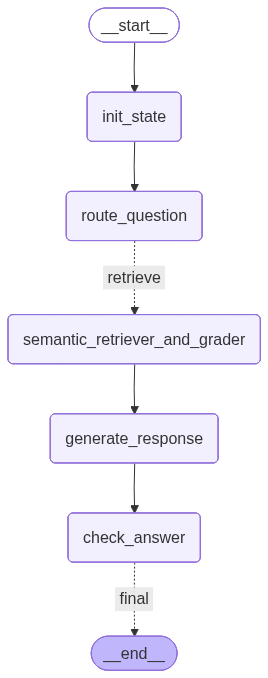

In [47]:
## YELLOW ##
# Create the graph
workflow = StateGraph(GraphState)

# Add the appropriate nodes
workflow.add_node("init_state", init_graph_state)
workflow.add_node("route_question", route_question_node)
workflow.add_node("semantic_retriever_and_grader", semantic_retrieve_w_scores)
workflow.add_node("generate_response", generate_response)
workflow.add_node("check_answer", check_answer_node)

# Start -> init_state
workflow.set_entry_point("init_state")

# Add edges
# init_state -> route_question
workflow.add_edge("init_state", "route_question")

# route_question -> websearch or retrieve (conditional)
workflow.add_conditional_edges("route_question", 
                  route_question_edge,
                  {
                    "retrieve": "semantic_retriever_and_grader" 
                  }
                  )

# retrieve -> generate
workflow.add_edge("semantic_retriever_and_grader", "generate_response")


# generate -> check_answer
workflow.add_edge("generate_response", "check_answer")

# check_answer -> websearch or END (conditional)
workflow.add_conditional_edges("check_answer",
                               decide_after_check,
                               {
                                   "final": END
                               }
                               )

# Compile the graph
app = workflow.compile()

## GREEN ##
display(Image(app.get_graph().draw_mermaid_png()))

In [48]:
question = "Explain how P314 fits into the POM26 policy?"
logger.setLevel(logging.INFO)
result = app.invoke({"question": question})

print()
print(f"=====================")
print(f"Question: {question}")
print(f"\nAnswer: {result['generation']}")
print(f"\nNumber of documents retrieved: {len(result['documents'])}")
print(f"\nGeneration attempts: {result['gen_attempts']}")

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: both
INFO - EDGE: route_question_edge sees route='both'
/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_38207/3236383540.py:31: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='203', metadata={'source': 'docs/projects/P314.pdf', 'impact_if_not_provided': 'CNE/CNA/C6F commanders will be forced to operate in an undersized, ill-configured and inadequately-capable MOC, thereby continuing to sub-optimize MOC staff effectiveness and efficiency impacting quality of staff decision-support products ultimately affecting Fleet operational C2. An appropriately sized and configured MOC facility to fully support the EURAFCENT operational tempo is impossible without this project. All exercises and contingency operations will have to be relocated.', 'title': 'Naval Fleet Mission Operations Command and Control', 'CCN': 14380, 'id': '203', 'lead_proponent': '


Question: Explain how P314 fits into the POM26 policy?

Answer: I don't know.

Number of documents retrieved: 6

Generation attempts: 1


In [49]:
# In your notebook, after app is defined:
from eval.eval_task1 import eval_rag_chain_proj_query

# Wrap app.invoke to match the expected interface (takes string, returns string)
agent_as_chain = RunnableLambda(
    lambda question: app.invoke({"question": question, "k": 6})["generation"]
)

eval_rag_chain_proj_query(agent_as_chain, q_num=15)

INFO - NODE: Initialize State
INFO - NODE: Route Question - Determining data source
INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_38207/3236383540.py:31: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='264', metadata={'CCN': 73025, 'source': 'docs/projects/P736.pdf', 'CWE': 16860, 'region': 'CNR EU', 'impact_if_not_provided': 'U.S. personnel entering and onboard NAS I will remain as soft targets vulnerable to attacks by terrorist or violent criminals and will remain vulnerable to vehicle-borne improvised explosive devices (VBIED) or active shooters.', 'project_id': 'P736', 'id': '264', 'title': 'Entry Control Point (NAS I)', 'COCOM': 'EUCOM', 'installation': 'NAS SIGONELLA IT', 'scope': 'Derived from a preliminary design developed by the Surface Deployment and Distribution Command Transportation Engineering Agency (SDDCTEA) for an ECF/ACP Stu

Question: What is the Lead Proponent Severity Statement score for project P736 Entry Control Point (NAS I)? A) 4 - This project will eliminate serious life safety hazards B) 2 - Project improves base operations efficiency by increasing vehicle and pedestrian throughput while minimizing ATFP risk C) 1 - Minor impact on daily operations with adequate existing workarounds D) 3 - ATFP risk high for important primary gathering facilities; critical assets assessed as high AT/FP risk and red operational gap E) 0 - No documented severity
Correct Response:  D) 3 - ATFP risk high for important primary gathering facilities; critical assets assessed as high AT/FP risk and red operational gap
Pipeline Response: E) 0 - No documented severity



INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
INFO -   Retrieved 6 documents total across 1 store(s)
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (176 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 6
  Context    : [doc0 score=0.54] {   "title": "HV SYSTEM REPAIRS, FEEDERS #2, 3, 4, AND 9",   "installation": "NAVSTA ROTA SP",   "CWE": 7147,   "CCN": 81231,   "region": "CNR EU",   "lead_proponent": "NAVFAC",   "COCOM": "EUCOM",   "scope": "This project will repair the medium and high voltage (HV) electrical distribution system in the Weapons, PWDand Retail, Core and Fuel areas  | [doc1 score=0.44] "region_mission_alignment": {     "description": "Project and improvements address six Region resiliency gaps identified in the 2019 Energy Mission Integration Group  Gap Analysis.  This project

Question: What is the project scope for RM19-0930 at NAVSTA Rota? A) Repair the medium and high voltage electrical distribution system in the Airfield and Industrial Facilities area, including undergrounding of 15kV feeders and installation of new SF6 pad-mounted switchgears B) Repair the medium and high voltage electrical distribution system in the Weapons, PWD, Retail, Core, and Fuel areas; install 278 power poles and associated copper conductors C) Upgrade and repair non-compliant aspects of the Jerez entry control point to meet Unified Facilities Criteria D) Repair the medium and high voltage distribution system supplying the Airfield and Air Operations facilities and EOD facilities E) Repair and renovate the wastewater collection and treatment systems at multiple locations at NSA Souda Bay Main Site and NMPC
Correct Response:  B) Repair the medium and high voltage electrical distribution system in the Weapons, PWD, Retail, Core, and Fuel areas; install 278 power poles and associat

INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_38207/3236383540.py:31: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='501', metadata={'scope': 'Constructs a new 64K SF high-bay warehouse facility for storage of furniture and personal items at Naval station (NAVSTA) Rota. Project will also build a 4k SF pre-engineered metal storage for more industrial type items. Project will demolish legacy substandard warehouses:  Bldg # 589 and Bldg# 1971', 'CWE': 41870, 'CCN': 71477, 'lead_proponent': 'CNIC', 'region': 'CNR EU', 'title': 'Housing Warehouse - Distribution Center', 'impact_if_not_provided': 'Annual off-base leasing cost will continue to serve in lieu of adequete storage space; witth the increase in mission expected with 2 additional FDNF ships crews and their dependants, demand wil increase for storage of FH and UH material aboard NAVSTA Rot

...

Question: What is the project scope for RM15-0945 at NAVSUPPACT Bahrain? A) Repair potable and fire water lines by replacing underground service pipe, valves, and fittings at NSA-I B) Repair HVAC, electrical, plumbing, fire protection, electronic entry control locks, doors, fixtures, conveying equipment, and interior finishes; reconfigure 2+2 layout to 2+0 C) Repair building deficiencies for the AIMD complex including major repairs to building envelopes, HVAC, mechanical, and electrical systems D) Repair and renovate the exterior and interior of munitions tunnel YK-9 and construct a reinforced concrete apron E) Reconfigure internal walls and repair HVAC, electrical, plumbing, fire protection, entry control locks, doors, fixtures, conveying equipment, and interior finishes of UH B263
Correct Response:  E) Reconfigure internal walls and repair HVAC, electrical, plumbing, fire protection, entry control locks, doors, fixtures, conveying equipment, and interior finishes of UH B263
Pipeline 

INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
/var/folders/fx/40x5kxf917zbl8ml3w_3tjfr0000gn/T/ipykernel_38207/3236383540.py:31: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='467', metadata={'id': '467', 'CWE': 45020, 'lead_proponent': 'CNIC N3', 'source': 'docs/projects/P998.pdf', 'region': 'CNR EU', 'title': 'CONSTRUCT AIRCRAFT MAINTENANCE HANGAR', 'impact_if_not_provided': "The Squadron mission's and the maintenance operations for aviation detachments tied to planned deployments of the Littoral Combat Ship to Bahrain will be detrimentally affected without an environmentally controlled hangar at Flight Line, Isa Air Base. Open field maintenance will not protect the craft or personnel from extreme weather conditions (125-131 F)in Bahrain, including high winds, sand storms, extreme heat, rain, and poor lighting (at night).", 'project_id': 'P998', 'installation': 'NAVSUPPACT BAHRAIN', 'CCN': 21104, 

Question: What is the mission of the facility for project P998 Construct Aircraft Maintenance Hangar at NAVSUPPACT Bahrain? A) Provide maintenance to air squadron units rotating through Isa AB approximately every six months and for aviation detachments tied to planned deployments of the Littoral Combat Ship to Bahrain, conducting crisis response and contingency operations in the CENTCOM AOR B) Provide aircraft maintenance and component repair services for aeronautical components in support of EUCOM, AFRICOM, and CENTCOM areas of operations C) Provide a pre-engineered maintenance hangar for P-8A Poseidon and Triton aircraft assigned to NSA Bahrain D) Provide consolidated GSE maintenance and administrative space for NAVCENT aviation assets E) Provide temporary aircraft storage and maintenance for transiting aircraft in the CENTCOM AOR
Correct Response:  A) Provide maintenance to air squadron units rotating through Isa AB approximately every six months and for aviation detachments tied to

INFO -   Routing decision: proj_vectorstore
INFO - EDGE: route_question_edge sees route='proj_vectorstore'
INFO -   Retrieved 6 documents total across 1 store(s)
INFO - NODE: Generate Response
INFO -   Prompt created with 2 messages
INFO -   Invoking LLM...
INFO -   Generated response (260 chars)
INFO - NODE: Checking if retrieved answer contains IDK
INFO - 
  ===== RAG CHECK =====
  Docs count : 6
  Context    : [doc0 score=0.46] "score": 4   },   "lead_proponent_severity_statement": {     "description": "Lead Proponent Urgency Statement: Region Urgency Statement:",     "score": 4   },   "region_urgency_statement": {     "description": "Failure to program in past FY has resulted in critical  warfighter capability gap. CLDJ missions are helpless to  depend on expeditionary e | [doc1 score=0.43] "region_mission_alignment": {     "description": "The project directly supports National Security global  posture and Combatant Commander resolve a critical  capability gap & strengthens critica

Question: What is the mission of the facility for project ST21-0170? A) Provide berthing accommodations for tenant commands and assigned personnel at CLDJ B) CLDJ has two separate central power plants, Prime Power 2 and Prime Power 3, which provide electrical power via expeditionary diesel engine-generator sets; the plants provide 90 percent of CLDJ's power and run at 90-100 percent capacity during summer months C) Provide 24/7 mission-critical communication requirements for U.S., NATO, and coalition forces operating in AFRICOM, CENTCOM, and EUCOM AORs D) Provide wastewater collection and treatment for the entire Naval Air Station Sigonella supporting U.S. and NATO forces E) Operate Building 64 as a central power plant for NAVSTA Rota Base
Correct Response:  B) CLDJ has two separate central power plants, Prime Power 2 and Prime Power 3, which provide electrical power via expeditionary diesel engine-generator sets; the plants provide 90 percent of CLDJ's power and run at 90-100 percent 